# Exploratory Data Analysis — Home Credit Default Risk

This notebook presents the same exploratory analysis used in `notebooks/eda.py`, split into notebook cells

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "credit_applicants.parquet"

df = pd.read_parquet(DATA_PATH)

print("Applicants:", len(df))
print("Features:", df.shape[1])
print("Unique applicants:", df["SK_ID_CURR"].nunique())
print("Duplicate applicants:", df["SK_ID_CURR"].duplicated().sum())
print("Observed default rate:", round(df["TARGET"].mean() * 100, 2), "%")


Applicants: 307511
Features: 140
Unique applicants: 307511
Duplicate applicants: 0
Observed default rate: 8.07 %


## Feature Categorization


In [2]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:", len(numeric_columns))
print("Categorical features:", len(categorical_columns))


Numeric features: 124
Categorical features: 16


## Data Quality and Missing Values


In [3]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

missing_summary.to_frame("Missing (%)")


,Missing (%)
COMMONAREA_AVG,69.872297
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_AVG,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MODE,68.354953
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953


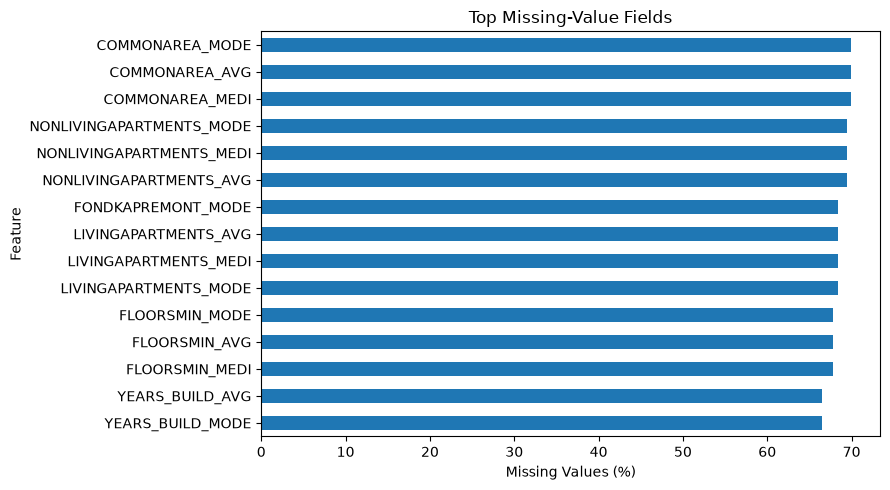

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_summary.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top Missing-Value Fields")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## Business Insight 1 — Historical Default Rate


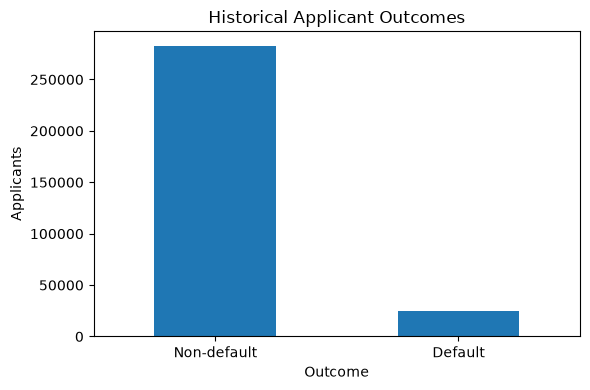

In [5]:
default_summary = df["TARGET"].value_counts().sort_index()
default_summary.index = ["Non-default", "Default"]

fig, ax = plt.subplots(figsize=(6, 4))
default_summary.plot(kind="bar", ax=ax)
ax.set_title("Historical Applicant Outcomes")
ax.set_xlabel("Outcome")
ax.set_ylabel("Applicants")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Business Insight 2 — External Credit Indicators


In [6]:
external_summary = (
    df.groupby("TARGET")[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
    .median()
    .T
)

external_summary.columns = ["Non-default", "Default"]
external_summary


,Non-default,Default
EXT_SOURCE_1,0.517452,0.361675
EXT_SOURCE_2,0.573905,0.440381
EXT_SOURCE_3,0.546023,0.379100


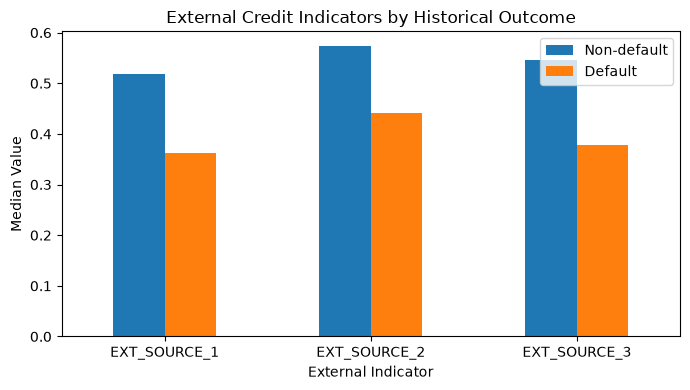

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
external_summary.plot(kind="bar", ax=ax)
ax.set_title("External Credit Indicators by Historical Outcome")
ax.set_xlabel("External Indicator")
ax.set_ylabel("Median Value")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Business Insight 3 — Employment Stability


In [8]:
employment_summary = df.groupby("TARGET")["EMPLOYMENT_YEARS"].median()
employment_summary.index = ["Non-default", "Default"]
employment_summary


Non-default    4.629706
Default        3.367556
Name: EMPLOYMENT_YEARS, dtype: float64

## Business Insight 4 — Historical Repayment Behaviour


In [9]:
repayment_summary = (
    df.groupby("TARGET")[["AVG_PAYMENT_DELAY", "LATE_PAYMENT_RATE"]]
    .median()
)

repayment_summary.index = ["Non-default", "Default"]
repayment_summary


,AVG_PAYMENT_DELAY,LATE_PAYMENT_RATE
Non-default,0.031579,0.016129
Default,0.139535,0.048387


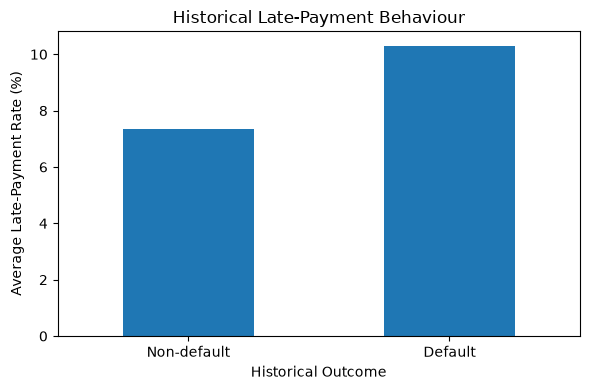

In [10]:
late_payment_mean = (
    df.groupby("TARGET")["LATE_PAYMENT_RATE"]
    .mean()
    .mul(100)
)

late_payment_mean.index = ["Non-default", "Default"]

fig, ax = plt.subplots(figsize=(6, 4))
late_payment_mean.plot(kind="bar", ax=ax)
ax.set_title("Historical Late-Payment Behaviour")
ax.set_xlabel("Historical Outcome")
ax.set_ylabel("Average Late-Payment Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Business Insight 5 — Credit Burden


In [11]:
credit_income_summary = df.groupby("TARGET")["CREDIT_INCOME_RATIO"].median()
credit_income_summary.index = ["Non-default", "Default"]
credit_income_summary


Non-default    3.266653
Default        3.253143
Name: CREDIT_INCOME_RATIO, dtype: float64

## Default Rate by Employment Tenure


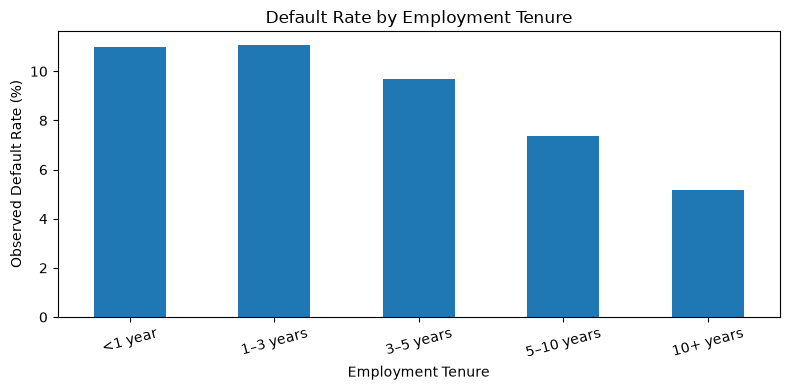

In [12]:
employment = df[["EMPLOYMENT_YEARS", "TARGET"]].dropna().copy()

employment["EMPLOYMENT_BAND"] = pd.cut(
    employment["EMPLOYMENT_YEARS"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=["<1 year", "1–3 years", "3–5 years", "5–10 years", "10+ years"],
    include_lowest=True,
)

employment_default_rate = (
    employment.groupby("EMPLOYMENT_BAND", observed=True)["TARGET"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 4))
employment_default_rate.plot(kind="bar", ax=ax)
ax.set_title("Default Rate by Employment Tenure")
ax.set_xlabel("Employment Tenure")
ax.set_ylabel("Observed Default Rate (%)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## EDA Summary

1. The portfolio has an observed historical default rate of approximately 8.07%, requiring imbalance-aware modelling.
2. External credit indicators show strong separation between historical default and non-default groups.
3. Historical defaulters have shorter median employment tenure.
4. Historical repayment delays and late-payment rates are higher among defaulters.
5. Credit-to-income ratio alone provides limited univariate separation and should be interpreted with broader credit and repayment information.
